<h2 style='color:blue' align="center">KNN (K Nearest Neighbors) Classification: Machine Tutorial Using Python Sklearn</h2>

<img height=300 width=300 src="iris_petal_sepal.png" />

In [1]:
from sklearn.datasets import load_iris
iris=load_iris()

In [2]:
iris.target_names

array(['setosa', 'versicolor', 'virginica'], dtype='<U10')

In [3]:
iris.feature_names

['sepal length (cm)',
 'sepal width (cm)',
 'petal length (cm)',
 'petal width (cm)']

In [4]:
import pandas as pd
df=pd.DataFrame(iris.data,columns=iris.feature_names)
df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


In [5]:
df["target"]=iris.target
df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


In [6]:
Setosa=df[df["target"]==0]
Versicolor=df[df["target"]==1]

**Sepal length vs Sepal Width (Setosa vs Versicolor)**

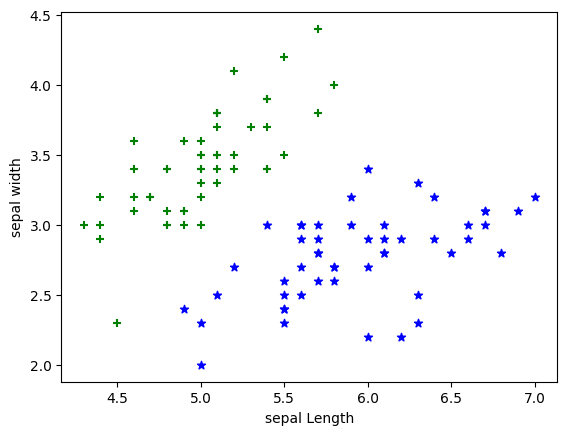

In [7]:
import matplotlib.pyplot as plt

plt.xlabel("sepal Length")
plt.ylabel("sepal width")
plt.scatter(Setosa["sepal length (cm)"],Setosa["sepal width (cm)"],marker="+",color="green")
plt.scatter(Versicolor["sepal length (cm)"],Versicolor["sepal width (cm)"],marker="*",color="blue")
plt.show()

**Petal length vs Pepal Width (Setosa vs Versicolor)**

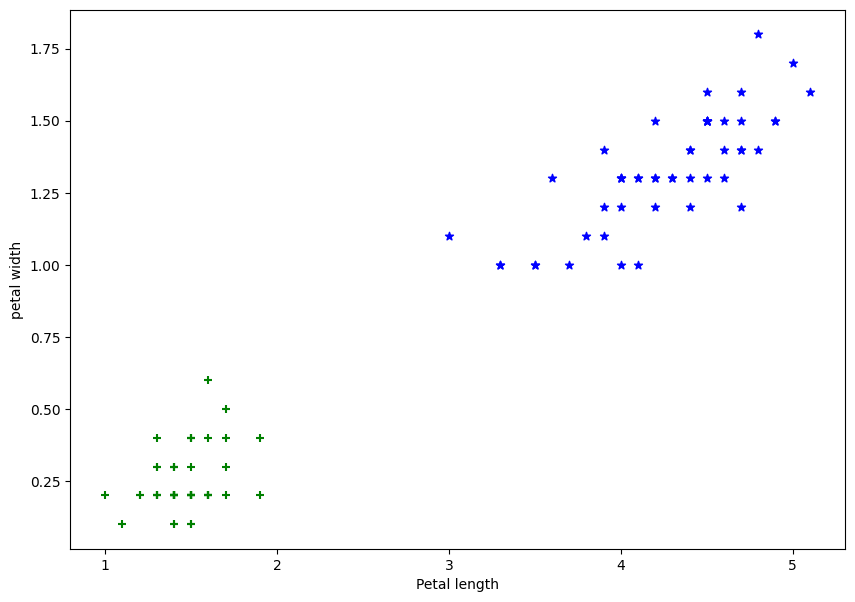

In [11]:
plt.figure(figsize=(10,7))
plt.xlabel("Petal length")
plt.ylabel("petal width")
plt.scatter(Setosa["petal length (cm)"],Setosa["petal width (cm)"],marker="+",color="green")
plt.scatter(Versicolor["petal length (cm)"],Versicolor["petal width (cm)"],marker="*",color="blue")
plt.show()


**Train test split**

In [15]:
X=df.drop(["target"],axis="columns")
y=df["target"]


In [16]:
from sklearn.model_selection import train_test_split

X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=20)

In [17]:
len(X_train)

120

In [18]:
len(X_test)

30

**Create KNN (K Neighrest Neighbour Classifier)**

In [23]:
from sklearn.neighbors import KNeighborsClassifier
knn=KNeighborsClassifier(n_neighbors=10)
knn.fit(X_train,y_train)

,n_neighbors,10
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [24]:
knn.score(X_train,y_train)

0.9666666666666667

In [25]:
knn.score(X_test,y_test)

1.0

In [26]:
y_pred=knn.predict(X_test)

**Plot Confusion Matrix**

In [28]:
from sklearn.metrics import confusion_matrix

cm=confusion_matrix(y_test,y_pred)
cm

array([[ 8,  0,  0],
       [ 0, 11,  0],
       [ 0,  0, 11]])

Text(50.722222222222214, 0.5, 'actual')

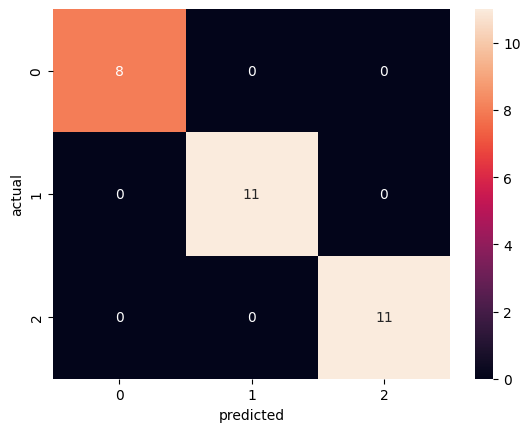

In [29]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.heatmap(cm,annot=True)
plt.xlabel("predicted")
plt.ylabel("actual")


**Print classification report for precesion, recall and f1-score for each classes**

In [30]:
from sklearn.metrics import classification_report

print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00         8
           1       1.00      1.00      1.00        11
           2       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30

